In [2]:
!pip install langchain
!pip install langgraph 
!pip install dotenv 


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for dotenv from https://files.pythonhosted.org/packages/b2/b7/545d2c10c1fc15e48653c91efde329a790f2eecfbbf2bd16003b5db2bab0/dotenv-0.9.9-py2.py3-none-any.whl.metadata
  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
  Obtaining dependency information for python-dotenv from https://files.pythonhosted.org/packages/5f/ed/539768cf28c661b5b068d66d96a2f155c4971a5d55684a514c1a0e0dec2f/python_dotenv-1.1.1-py3-none-any.whl.metadata
Using cached dotenv-0.9.9-py2.py3-none-any.whl (1.9 kB)



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install langchain-groq

  Obtaining dependency information for langchain-groq from https://files.pythonhosted.org/packages/c2/7d/7b5967f6bbe0248cebfee14a6e499873d81bbb761df6531d43ad166faf11/langchain_groq-0.3.6-py3-none-any.whl.metadata
  Obtaining dependency information for langchain-core<1.0.0,>=0.3.68 from https://files.pythonhosted.org/packages/f9/da/c89be0a272993bfcb762b2a356b9f55de507784c2755ad63caec25d183bf/langchain_core-0.3.68-py3-none-any.whl.metadata
  Obtaining dependency information for groq<1,>=0.29.0 from https://files.pythonhosted.org/packages/19/b8/5b90edf9fbd795597220e3d1b5534d845e69a73ffe1fdeb967443ed2a6cf/groq-0.30.0-py3-none-any.whl.metadata
  Obtaining dependency information for distro<2,>=1.7.0 from https://files.pythonhosted.org/packages/12/b3/231ffd4ab1fc9d679809f356cebee130ac7daa00d6d6f3206dd4fd137e9e/distro-1.9.0-py3-none-any.whl.metadata
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/131.1 kB ? eta -:--:--
   ---------


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#lets import the libraries 
from langgraph.graph import StateGraph,START ,END 
from dotenv import load_dotenv 
from langchain_groq import ChatGroq



In [7]:
load_dotenv() 


True

In [9]:
# #lets add a llm 
# llm=ChatGroq(model='Llama3-70b-8192') 
# llm.invoke('hi')
# AIMessage(content="Hi! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 11, 'total_tokens': 36, 'completion_time': 0.085449991, 'prompt_time': 0.001482154, 'queue_time': 0.055004155, 'total_time': 0.086932145}, 'model_name': 'Llama3-70b-8192', 'system_fingerprint': 'fp_dd4ae1c591', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--1fdedfc2-d294-4a57-b663-19a1d1398150-0', usage_metadata={'input_tokens': 11, 'output_tokens': 25, 'total_tokens': 36})


#it is working fine now we can use it 

In [10]:
from typing import TypedDict 
class Llm_state(TypedDict):
    question: str 
    answer: str 
    


In [ ]:
def llm_call(state: Llm_state)->Llm_state:
    question=state['question']
    prompt=f'Answer the following question  \n {question}'
    load_dotenv()
    llm=ChatGroq(model='Llama3-70b-8192') 
    response=llm.invoke(prompt).content 
    state['answer']=response
    return state 

In [13]:
graph=StateGraph(Llm_state)

graph.add_node('llm_call',llm_call)
graph.add_edge(START,'llm_call')
graph.add_edge('llm_call',END)

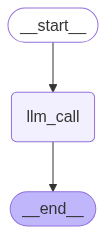

In [15]:
#lets make a workflow of our graph 
workflow=graph.compile() 
workflow

In [ ]:
initial_state={'question': ' tell me what is machine learning'}
final_state=workflow.invoke(initial_state)
print(final_state)


{'question': ' tell me what is machine learning', 'answer': '**What is Machine Learning?**\n\nMachine learning (ML) is a subfield of artificial intelligence (AI) that involves the development of algorithms and statistical models that enable machines to learn from data, make decisions, and improve their performance on a task without being explicitly programmed.\n\nIn traditional programming, a computer is given a set of rules and instructions to follow. However, in machine learning, the computer is given data and is expected to learn from that data and make predictions, classify objects, or make decisions on its own.\n\nMachine learning is based on the idea that a machine can be trained on data and then use that training to make predictions or take actions on new, unseen data. This is achieved through various types of algorithms, including:\n\n1. **Supervised Learning**: The machine is trained on labeled data, where the correct output is already known. The algorithm learns to map inputs

In [18]:
print(final_state['answer'])

**What is Machine Learning?**

Machine learning (ML) is a subfield of artificial intelligence (AI) that involves the development of algorithms and statistical models that enable machines to learn from data, make decisions, and improve their performance on a task without being explicitly programmed.

In traditional programming, a computer is given a set of rules and instructions to follow. However, in machine learning, the computer is given data and is expected to learn from that data and make predictions, classify objects, or make decisions on its own.

Machine learning is based on the idea that a machine can be trained on data and then use that training to make predictions or take actions on new, unseen data. This is achieved through various types of algorithms, including:

1. **Supervised Learning**: The machine is trained on labeled data, where the correct output is already known. The algorithm learns to map inputs to outputs based on the labeled data.
2. **Unsupervised Learning**: 